--- Loading simulation results ---
Loading existing combined dataset from: ../data/sim_results\combined_dataset.csv

Successfully loaded 270 simulation results
Data shape: (270, 51)
Tactics: ['divide_over_risks', 'horizontal_scan_traversal', 'partitioned_horizontal_scan_traversal', 'random_walk', 'spiral_traversal_swarm', 'together_traverse_best_permutation']
Hiding strategies: ['greedy', 'random', 'weighted']
Swarm sizes: [np.int64(1), np.int64(5), np.int64(10)]
N hiders: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

--- Generating All Plots ---

5. Creating multi-metric comparison...

All plots generated. Displaying interactive windows...


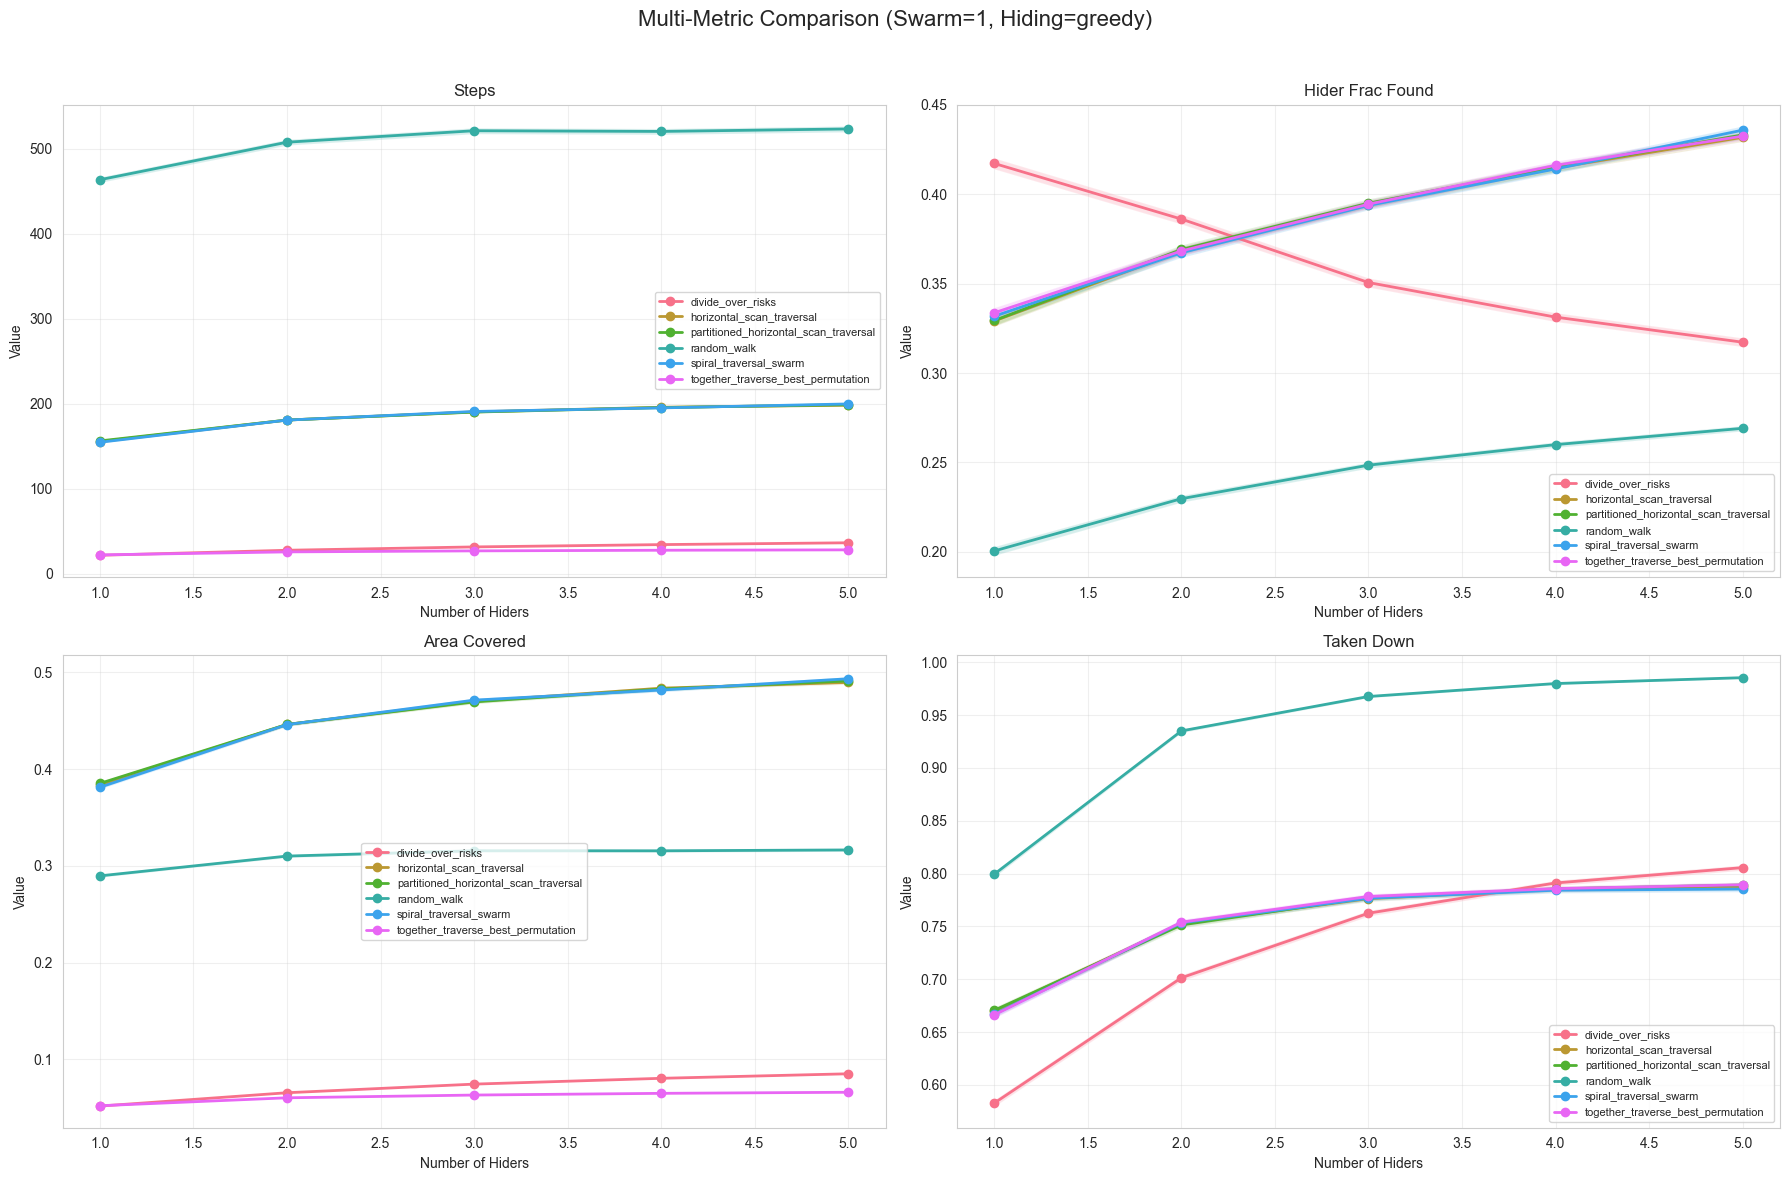

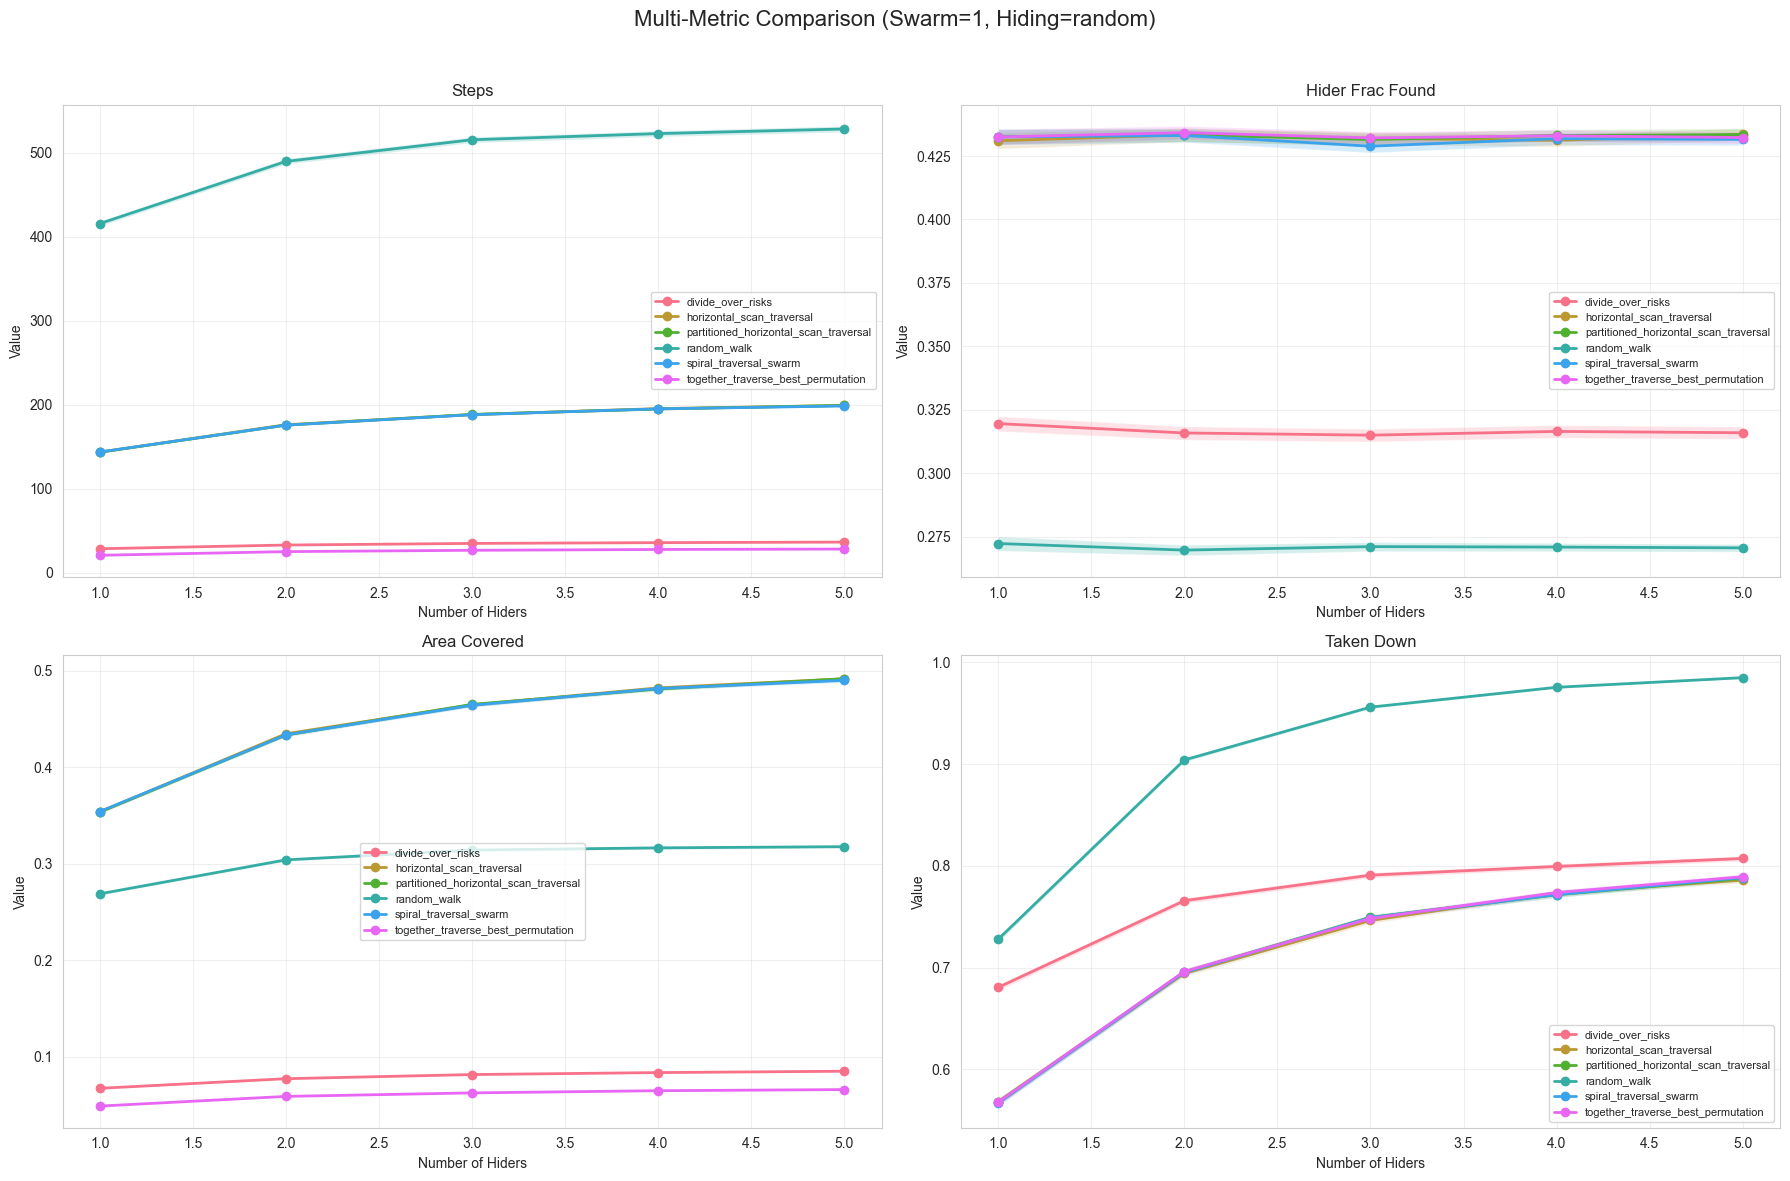

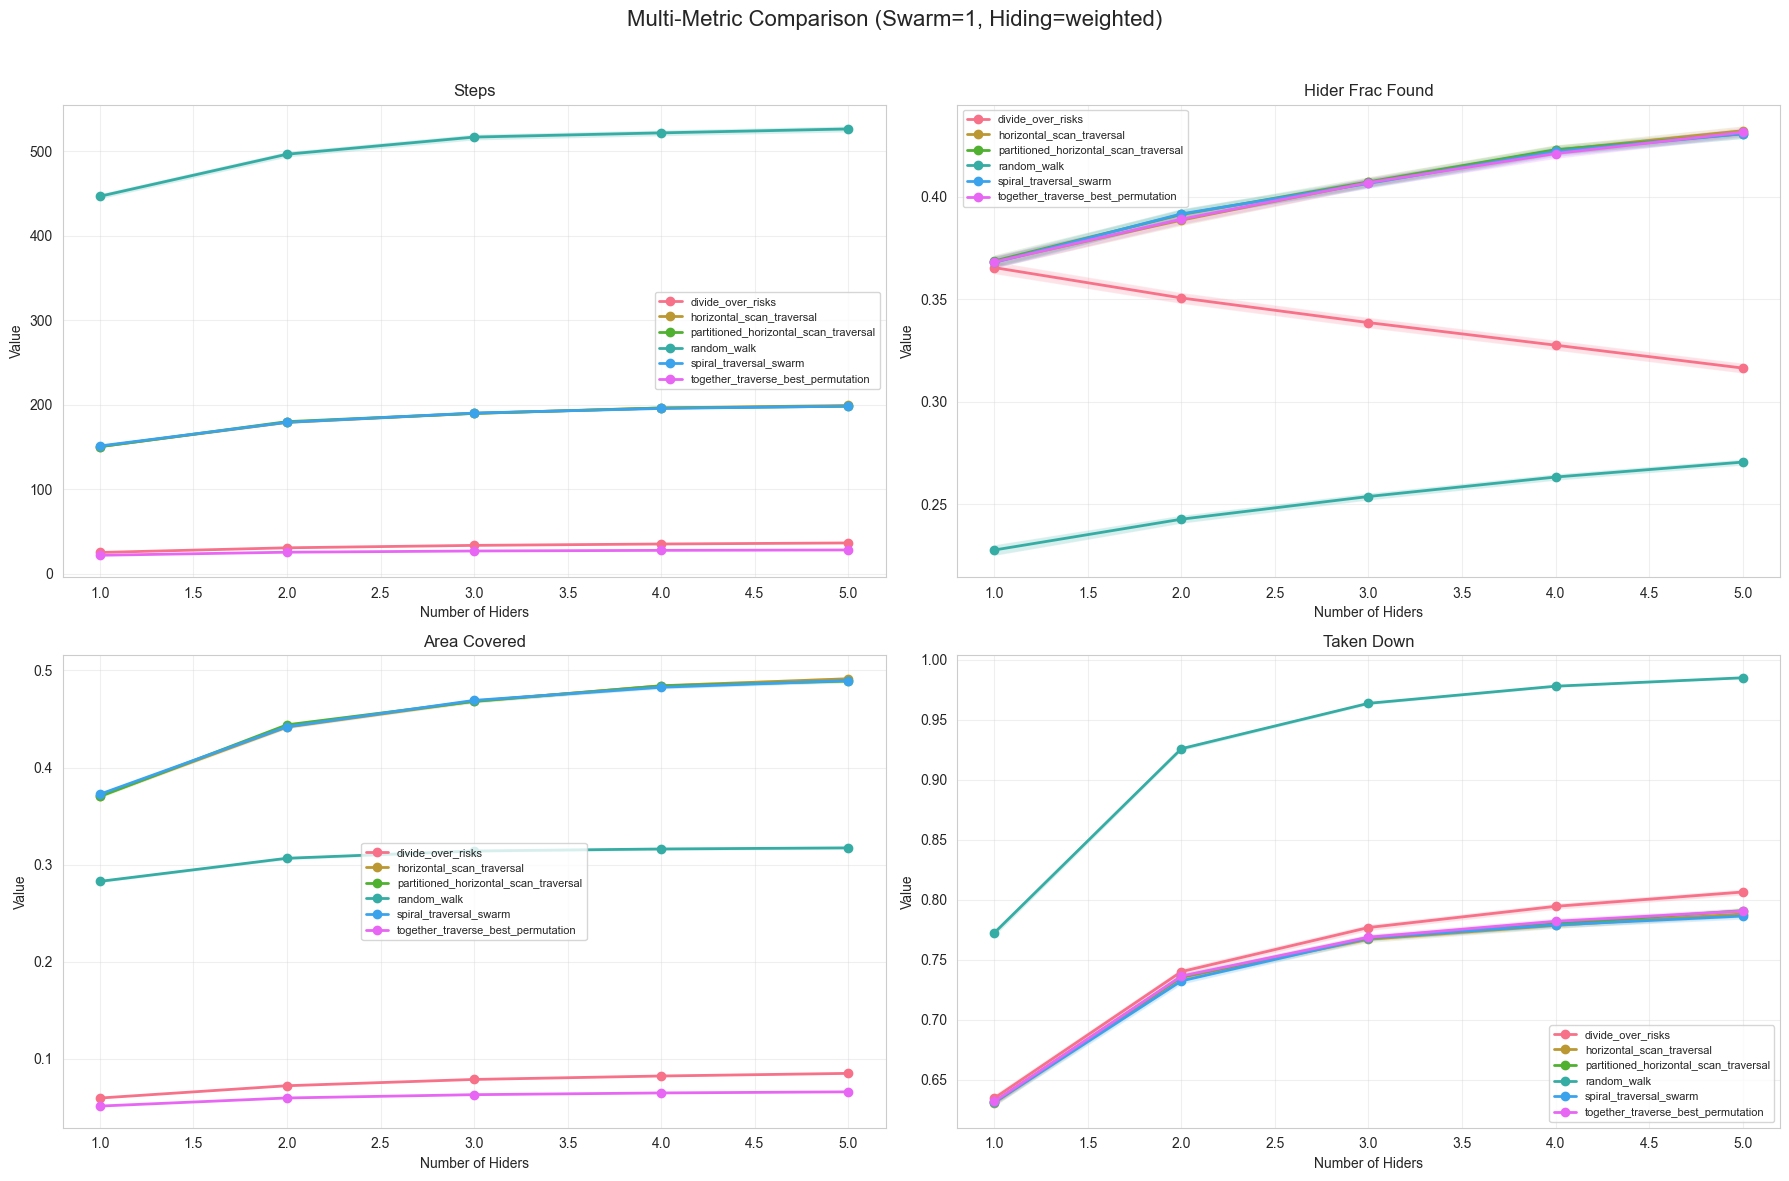

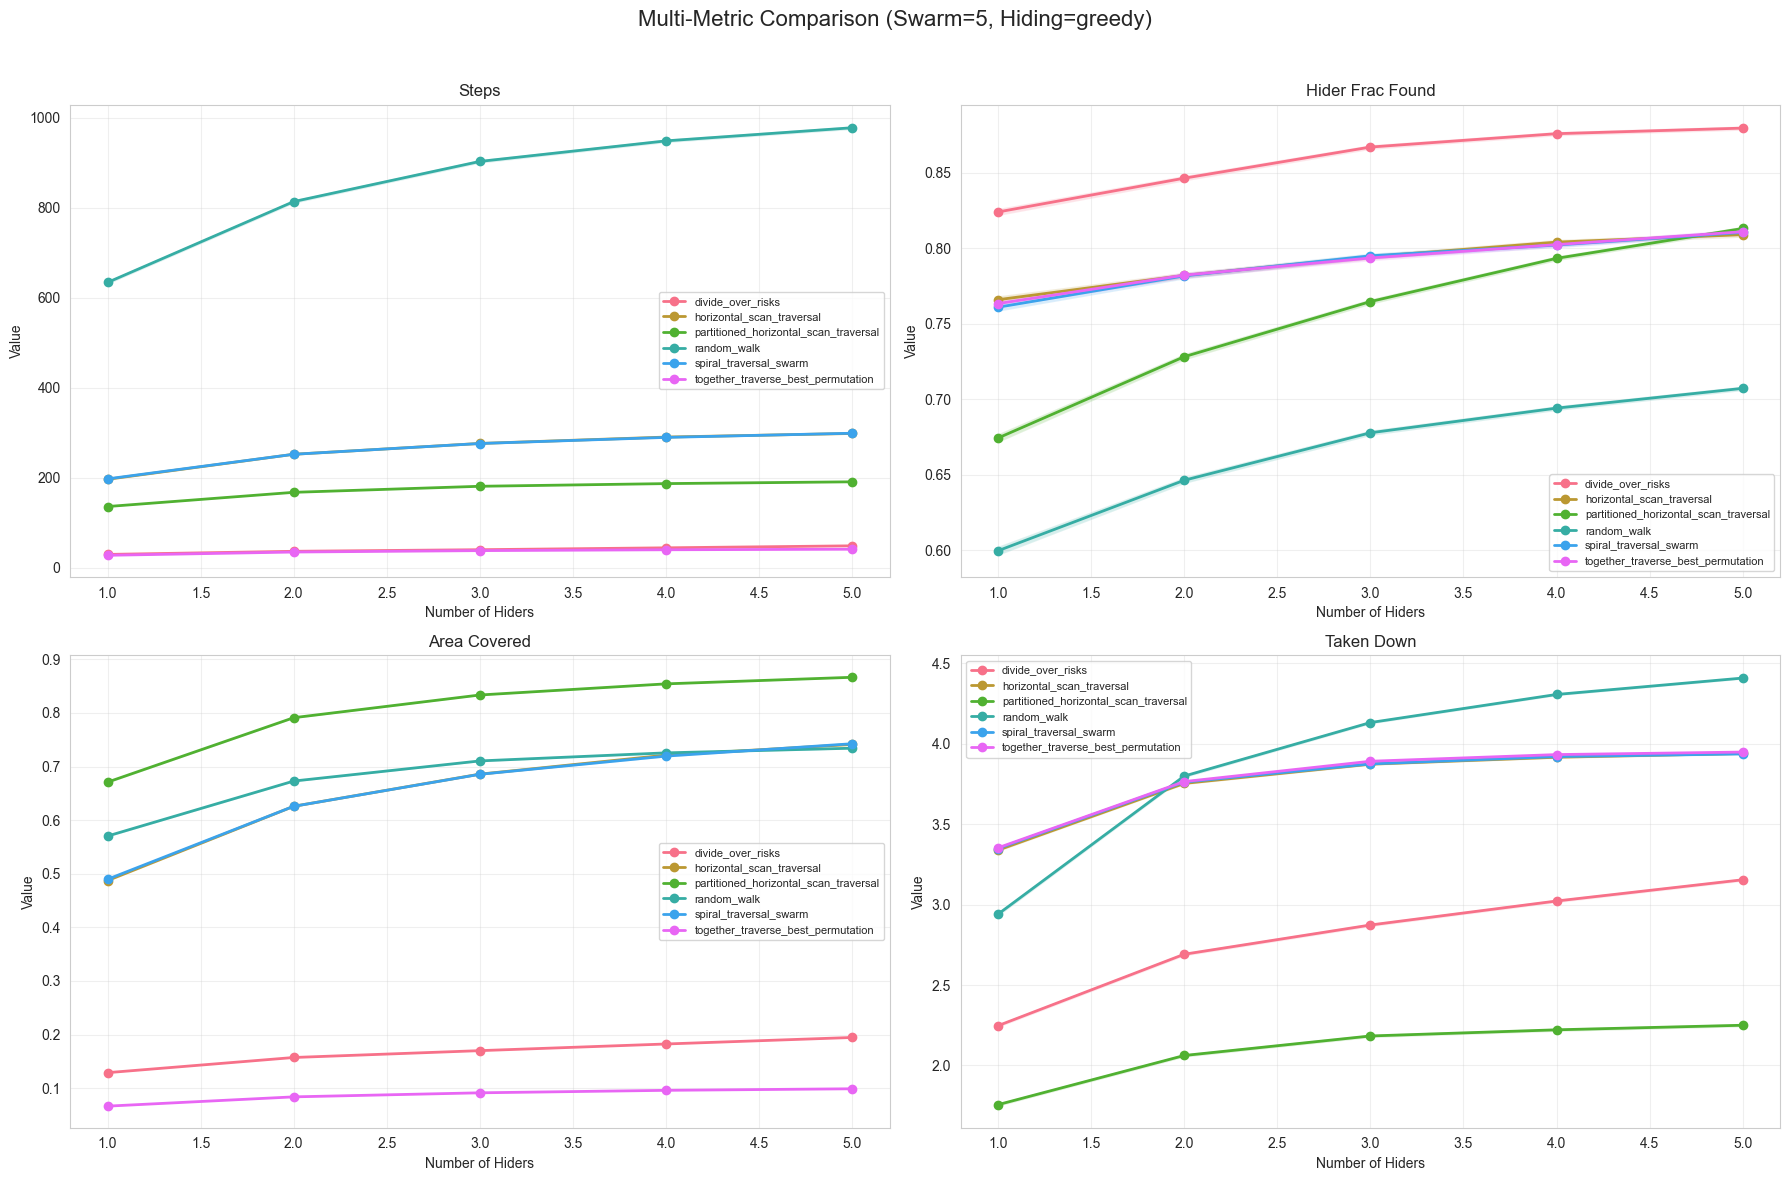

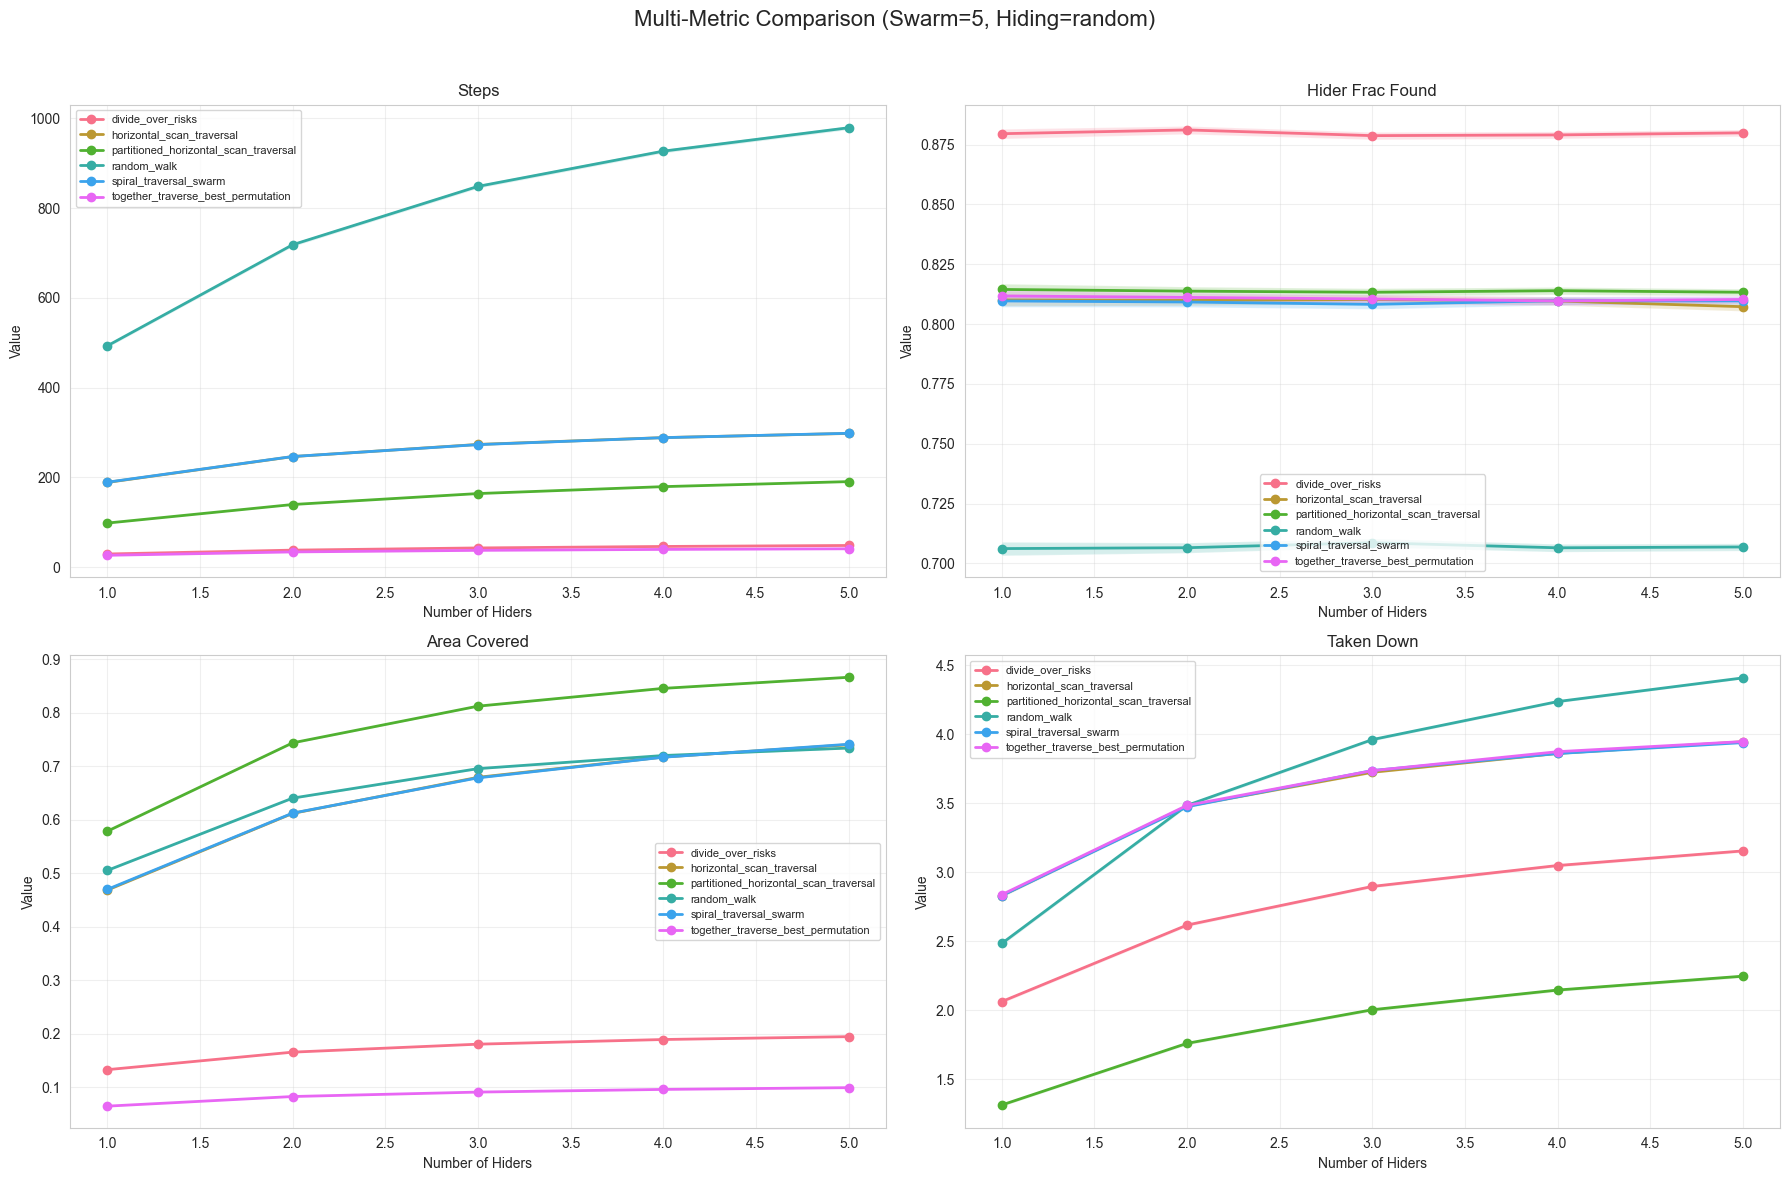

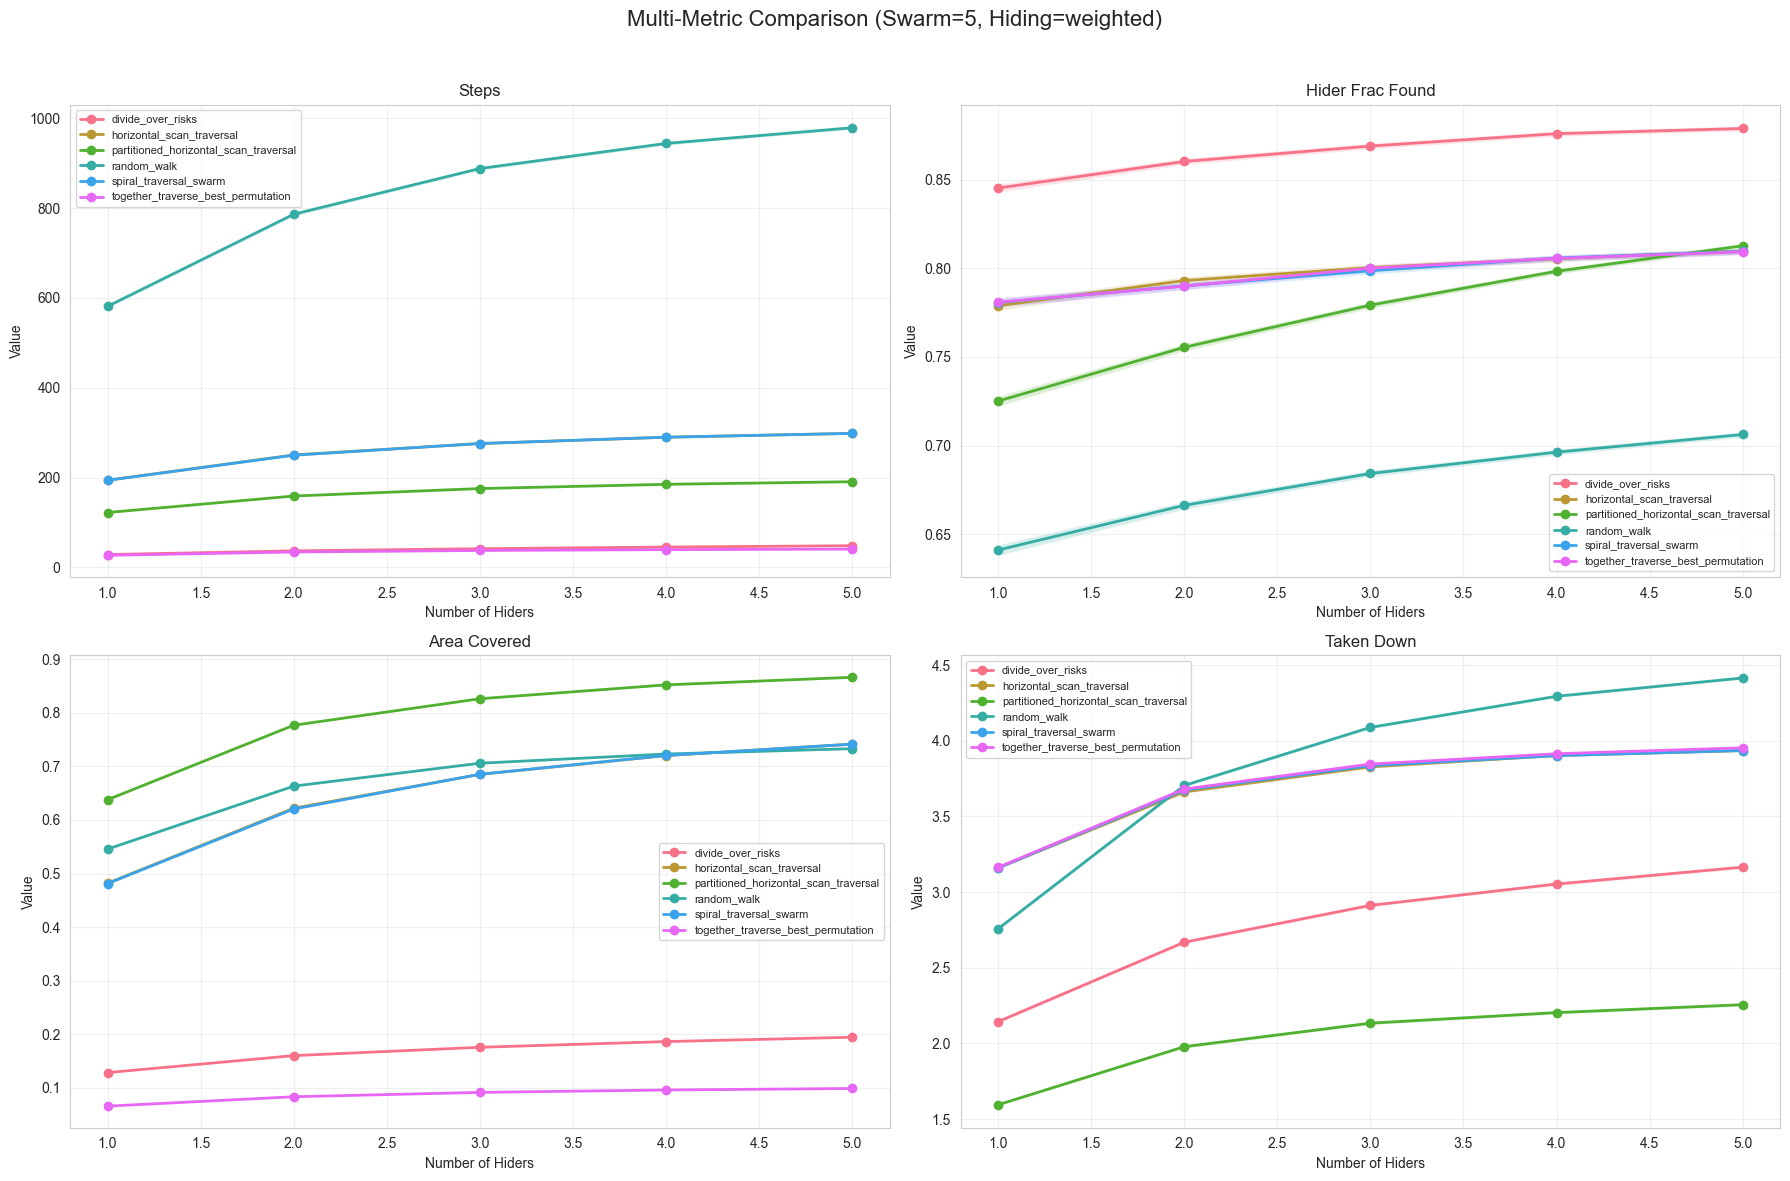

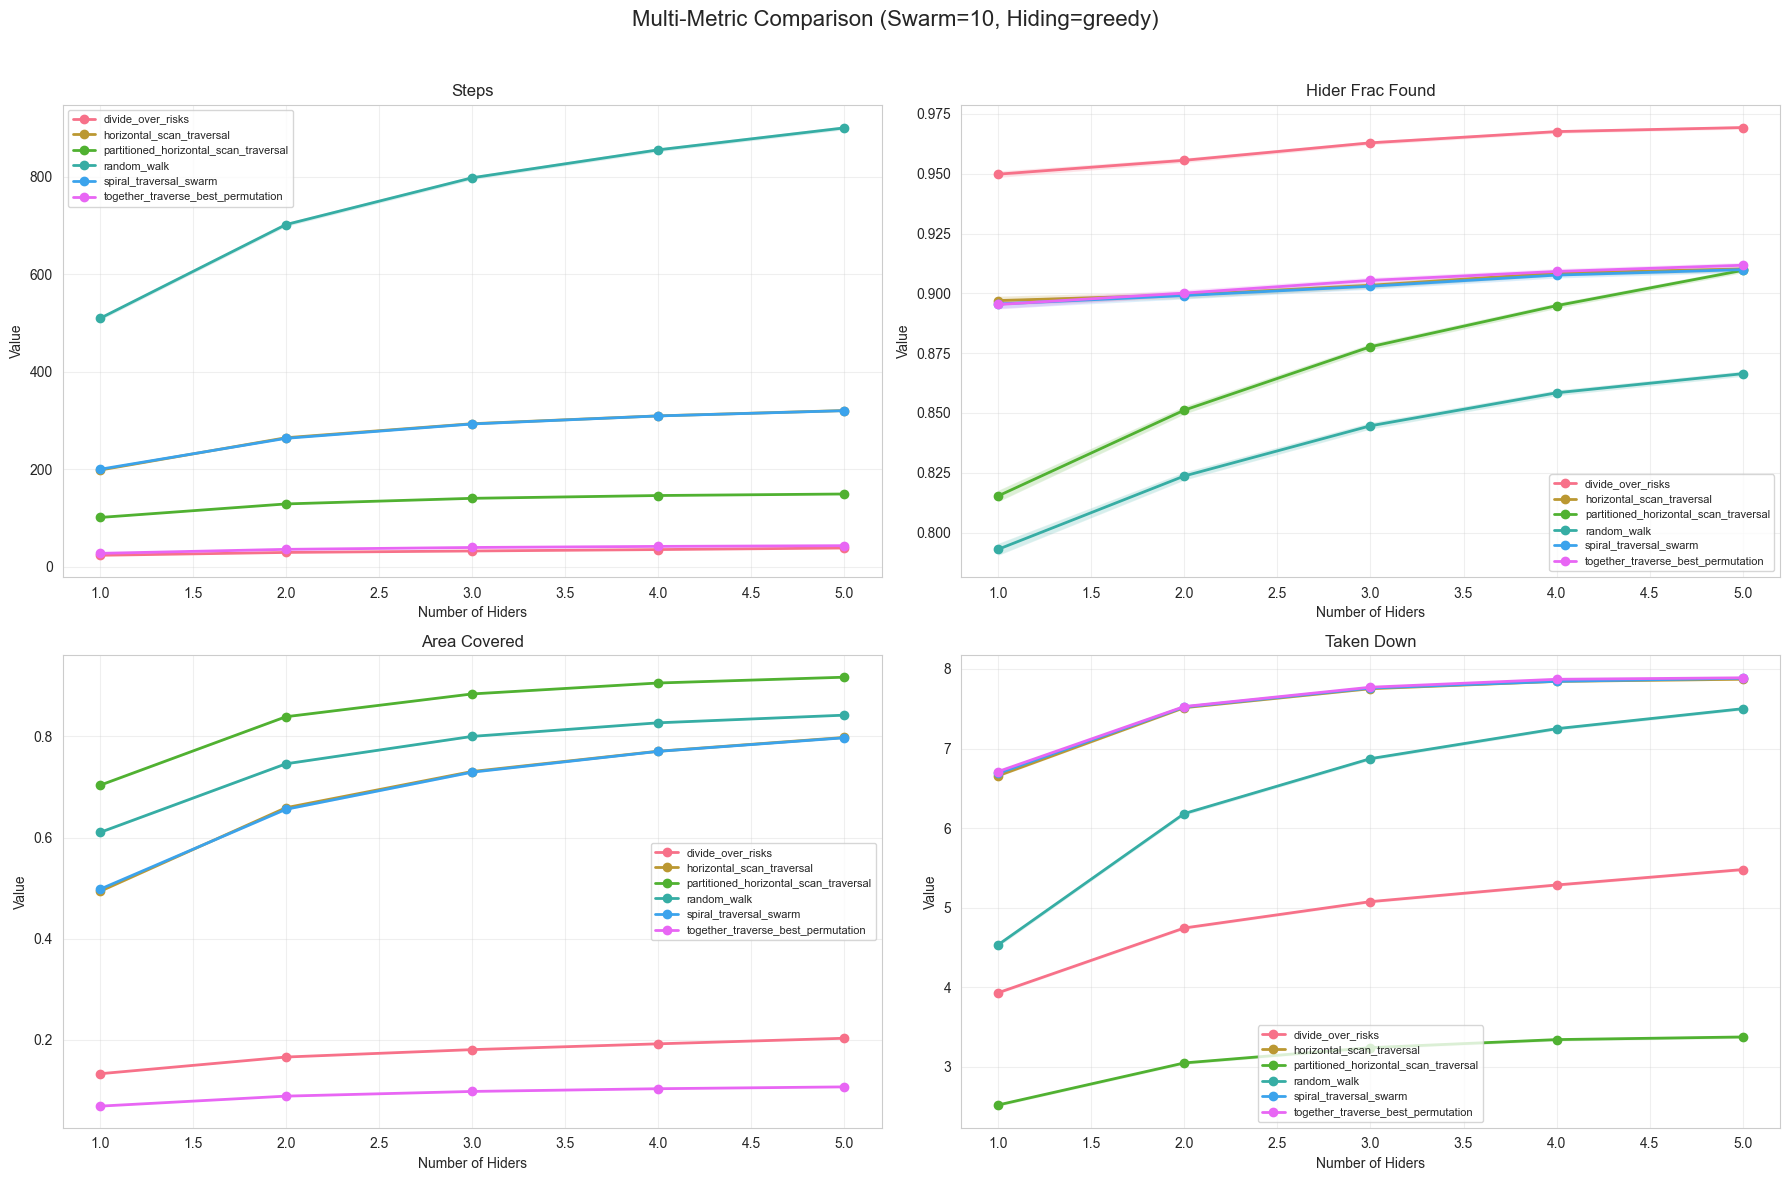

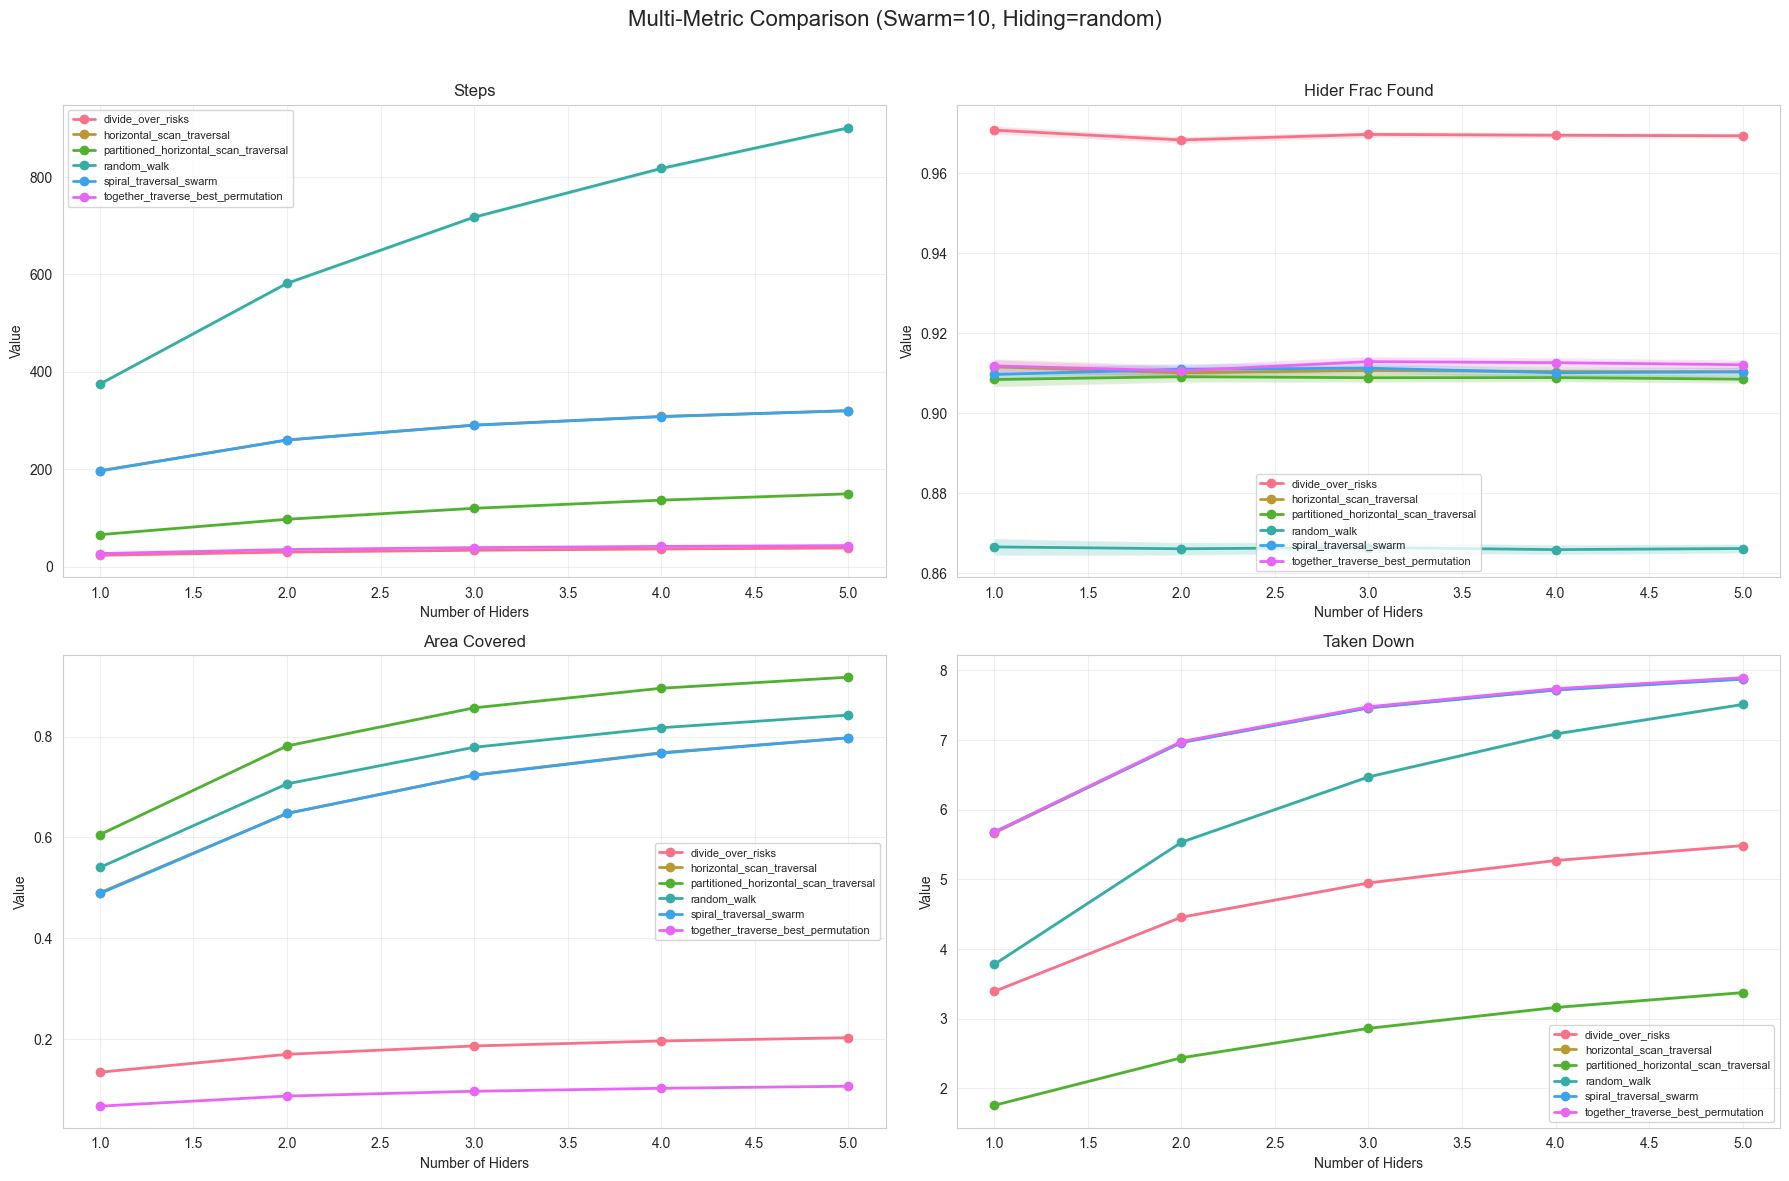

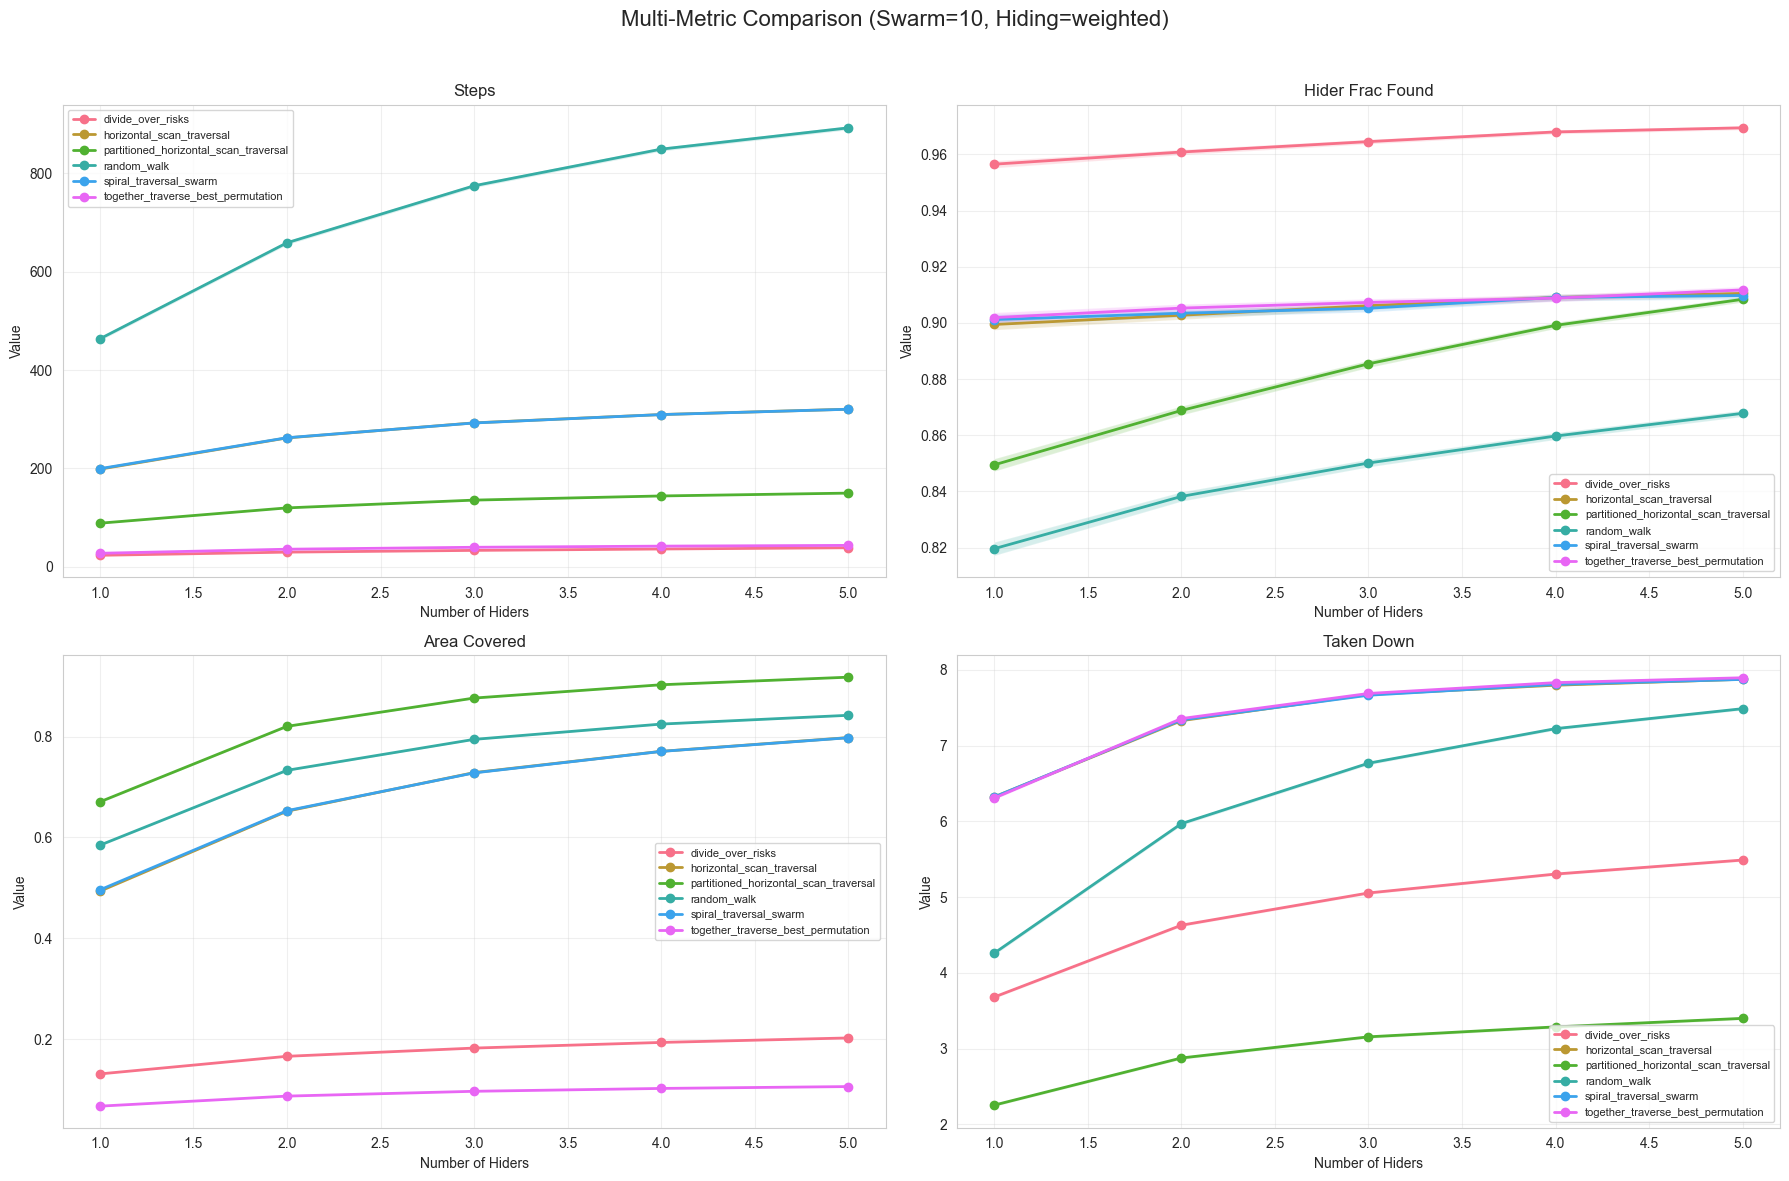

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import glob
from pathlib import Path
import sys

# --- Configuration ---
sns.set_palette("husl")
DATA_PATH = "../data/sim_results"

def parse_filename(filename):
    """
    Parse filename format:
    T-{tactic}-W-{width}-HS-{hide_strategy}-D-{swarm_size}-C-{n_hider_candidates}-H-{n_hiders}-RUNS-{runs}.csv
    """
    # Remove .csv and split by '-'
    parts = os.path.basename(filename).replace('.csv', '').split('-')
    try:
        return {
            'tactic': parts[1],
            'width': int(parts[3]),
            'hide_strategy': parts[5],  # FIX: Changed from hiding_strategy
            'swarm_size': int(parts[7]),
            'n_hider_candidates': int(parts[9]),
            'n_hiders': int(parts[11]),
            'runs': int(parts[13])
        }
    except (IndexError, ValueError) as e:
        print(f"Warning: Could not parse filename '{filename}'. Error: {e}")
        return None


def load_all_results(data_path=DATA_PATH, force_rebuild=False):
    """
    Load all individual CSV files, combine them, and save as combined_dataset.csv.
    If combined_dataset.csv exists, load it directly unless force_rebuild=True.
    """
    combined_csv_path = os.path.join(data_path, "combined_dataset.csv")

    # 1. Try loading the existing combined file first
    if not force_rebuild and os.path.exists(combined_csv_path):
        print(f"Loading existing combined dataset from: {combined_csv_path}")
        try:
            return pd.read_csv(combined_csv_path)
        except Exception as e:
            print(f"Warning: Could not load combined dataset: {e}. Rebuilding...")

    # 2. If it fails or force_rebuild=True, build from raw files
    print("Building combined dataset from raw CSV files...")
    records = []

    # Find all CSVs in the directory
    csv_files = glob.glob(os.path.join(data_path, "*.csv"))

    if not csv_files:
        print(f"Error: No raw CSV files found in {data_path}")
        return pd.DataFrame()  # Return empty DF

    for filepath in csv_files:
        filename = os.path.basename(filepath)

        # Skip the combined file itself
        if filename == "combined_dataset.csv":
            continue

        params = parse_filename(filename)
        if params is None:
            continue  # Skip files that can't be parsed

        try:
            # Use the separator from inspiration code, as it's for raw files
            df = pd.read_csv(filepath, sep=r"\s+", index_col=0)
        except Exception as e:
            print(f"Warning: Skipping file. Could not read '{filename}'. Error: {e}")
            continue

        record = {
            "tactic": params['tactic'],
            "hide_strategy": params['hide_strategy'],  # FIX: Changed from hiding_strategy
            "swarm_size": params['swarm_size'],
            "n_hiders": params['n_hiders'],
            "n_hider_candidates": params['n_hider_candidates'],
            "width": params['width'],
            "runs": params['runs'],
        }

        # --- Map Metric Names ---
        # Map names from raw files (e.g., 'steps') to names
        # expected by your original plotter (e.g., 'steps_mean')
        metrics_map = {
            'steps': 'steps',
            'taken_down': 'taken_down',
            'area_covered': 'area_covered',
            'mean_distance_travelled': 'mean_distance_travelled',
            'total_distance_covered': 'total_distance_covered',
            'hider_frac_found': 'hider_frac_found'
        }

        for metric_in_file, metric_out_col in metrics_map.items():
            if metric_in_file in df.index:
                # Add columns for BOTH original and new plotters
                mean = df.loc[metric_in_file, "mean"]
                hw = df.loc[metric_in_file, "Half_width"]
                ci_low = df.loc[metric_in_file, "ci_lower"]
                ci_up = df.loc[metric_in_file, "ci_upper"]

                # For your original plotter
                record[f"{metric_out_col}_mean"] = mean
                record[f"{metric_out_col}_half_width"] = hw

                # For new plotters from inspiration
                # FIX: Changed to _ci_lower and _ci_upper to match CSV and avoid KeyError
                record[f"{metric_out_col}_ci_lower"] = ci_low
                record[f"{metric_out_col}_ci_upper"] = ci_up
                # FIX: Removed redundant '_hw' column. We will use '_half_width' everywhere.

        if 'Found' in df.index:
            found_val = df.loc["Found", "min"]
            record["found_percentage"] = float(str(found_val).strip("%"))

        records.append(record)

    if not records:
        print("Error: No valid data records were built.")
        return pd.DataFrame()

    combined_df = pd.DataFrame(records)

    # 3. Save the new combined file
    try:
        combined_df.to_csv(combined_csv_path, index=False)
        print(f"Saved new combined dataset to: {combined_csv_path}")
    except Exception as e:
        print(f"Error saving combined dataset: {e}")

    return combined_df

def plot_multi_metric_comparison(data, metrics=['steps', 'area_covered',
                                                'hider_frac_found', 'taken_down']):
    """4-panel plot showing multiple metrics for quick comparison"""

    for swarm in sorted(data['swarm_size'].unique()):
        for strat in sorted(data['hide_strategy'].unique()):
            fig, axes = plt.subplots(2, 2, figsize=(18, 12))
            axes = axes.flatten()

            # Example config: Filter for one swarm size and hiding strategy
            # You can change these values
            FILTER_SWARM_SIZE = swarm
            FILTER_HIDE_STRATEGY = strat

            subset = data[(data['swarm_size'] == FILTER_SWARM_SIZE) &
                          (data['hide_strategy'] == FILTER_HIDE_STRATEGY)]  # FIX: Changed from hiding_strategy

            if subset.empty:
                print(
                    f"Skipping multi-metric plot: No data for swarm_size={FILTER_SWARM_SIZE} and strategy='{FILTER_HIDE_STRATEGY}'")
                plt.close(fig)
                return

            for ax, metric in zip(axes, metrics):
                for tactic in sorted(subset['tactic'].unique()):
                    tactic_data = subset[subset['tactic'] == tactic].sort_values('n_hiders')

                    if tactic_data.empty:
                        continue

                    ax.plot(tactic_data['n_hiders'], tactic_data[f'{metric}_mean'],
                            marker='o', label=tactic, linewidth=2)

                    # FIX: Changed to _ci_lower and _ci_upper to match CSV
                    ax.fill_between(tactic_data['n_hiders'],
                                    tactic_data[f'{metric}_ci_lower'],
                                    tactic_data[f'{metric}_ci_upper'], alpha=0.2)

                ax.set_title(metric.replace('_', ' ').title())
                ax.set_xlabel("Number of Hiders")
                ax.set_ylabel("Value")
                ax.grid(True, alpha=0.3)
                ax.legend(fontsize=8)

            plt.suptitle(f"Multi-Metric Comparison (Swarm={FILTER_SWARM_SIZE}, Hiding={FILTER_HIDE_STRATEGY})", fontsize=16)
            plt.tight_layout(rect=[0, 0, 1, 0.96])

# --- Main execution ---
if __name__ == "__main__":
    # Load data
    print("--- Loading simulation results ---")
    # Set force_rebuild=True if you have new raw CSV files
    all_data = load_all_results(force_rebuild=False)

    if all_data.empty:
        print("\nNo data loaded. Exiting.")
    else:
        # --- Check for essential columns ---
        # This helps debug if 'combined_dataset.csv' is old or malformed
        required_columns = ['tactic', 'hide_strategy', 'swarm_size', 'n_hiders']  # FIX: Changed from hiding_strategy
        missing_cols = [col for col in required_columns if col not in all_data.columns]

        if missing_cols:
            print(f"\nError: The loaded DataFrame is missing essential columns: {missing_cols}")
            print("This often happens if the 'combined_dataset.csv' file is old or malformed.")
            print(
                "Try setting 'force_rebuild=True' in the 'load_all_results(force_rebuild=True)' call in this script to regenerate it from raw files.")
            # We exit here because the plotting functions will fail
            sys.exit(1)

        # If check passes, proceed with printing and plotting
        print(f"\nSuccessfully loaded {len(all_data)} simulation results")
        print(f"Data shape: {all_data.shape}")
        print(f"Tactics: {sorted(all_data['tactic'].unique())}")
        print(f"Hiding strategies: {sorted(all_data['hide_strategy'].unique())}")  # FIX: Changed from hiding_strategy
        print(f"Swarm sizes: {sorted(all_data['swarm_size'].unique())}")
        print(f"N hiders: {sorted(all_data['n_hiders'].unique())}")

    # --- Generate all plots ---
        print("\n--- Generating All Plots ---")

        # Key metrics to analyze (using root names)
        key_metrics = ['steps', 'hider_frac_found', 'area_covered', 'taken_down']

        print("\n5. Creating multi-metric comparison...")
        plot_multi_metric_comparison(all_data, metrics=key_metrics)

        # --- ADD THIS LINE ---
        print("\nAll plots generated. Displaying interactive windows...")
        plt.show()
        # ---------------------


